# Decodier-Algorithmus

## Importe

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Parametereinstellung für die Reproduzierbarkeit

In [2]:
#Hier werden für die Reproduzierbarkeit Parameter gesetzt. 
#Damit können die Abläufe in der Arbeit nachvollzogen werden
#dazu zählen: Text, Anzahl der Iterationen, Seed, Sprache des Texts

text1=[]#für eigenen Test
text2='''you were born to be real not to be perfect'''
text3='''We call that which our calculations fail to explain coincidence. Let us turn to the proof, taking as an example... 
This principle is so completely general that no application is possible. Love is an equation with two unknowns.'''
text4='''Who's riding so late where winds blow wild? It is the father grasping his child; He holds the boy embraced in his arm,
He clasps him snugly, he keeps him warm."My son, why cover your face in such fear?""You see the elf-king, father? He's near!
The king of the elves with crown and train!""My son, the mist is on the plain."'''
text5='''Lieber den Spatz in der Hand als die Taube auf dem Dach. Es ist noch kein Meister vom Himmel gefallen. 
Was du heute kannst besorgen, das verschiebe nicht auf Morgen. Wer rastet, der rostet. Der Teufel steckt im Detail.'''

#Sprache
e='englisch'
d='deutsch'

#Iterationen
it1=[]#für eigenen Test
it2=10**4
it3=10**6
it4=2*10**4
it5=5*10**3

#Durchlauf
Seed1=None #für eigenen Test 
Seed2=42
Seed3=123
Seed4=138
Seed5=3

### Legende der Abbildungen

In [3]:
#Legende zu den Abbildungen

#text3, it5, Seed4-->Konvergenz nach 4292 Schritten, gelungene Entschlüsselung
#Abb.9: text2, it2, Seed2-->stark schwankend und keine Konvergenz
#Abb.10: text2, it3, Seed2-->sehr stark schwankend und keine Konvergenz (Vorsicht lange Laufzeit)
#Abb.11: text3, it4, Seed2-->Konvergenz nach 18197 Schritten
#Abb.12: text4, it3, Seed2-->lokales Maximum (Vorsicht lange Laufzeit)
#deutsche Entschlüsselung: text5, it2, Seed5 nach 6960 Schritten

### Parameter setzen

In [4]:
#Setzen der aktuellen Parameter für den Durchlauf
text=text3
it=it5
Seed=Seed4
np.random.seed(Seed)
#für deutsch oder englisch:
wahrscheinlichkeit=e #für englischen Text bitte e wählen und für deutsch bitte d wählen

## Einlesen der Datei

In [5]:
#Festlegen der Spaltennamen
spalten_namen=['Buchstabe1','Buchstabe2', 'Quelle1_abs', 'Quelle2_abs', 'Quelle3_abs', 'Quelle4_abs', 'Quelle5_abs', 'Quelle1_rel', 'Quelle2_rel', 'Quelle3_rel', 'Quelle4_rel', 'Quelle5_rel']
#Import
data=pd.read_csv("BigramWhk_klein.txt",sep='\t',header=None, names=spalten_namen)
data.head()

,Buchstabe1,Buchstabe2,Quelle1_abs,Quelle2_abs,Quelle3_abs,Quelle4_abs,Quelle5_abs,Quelle1_rel,Quelle2_rel,Quelle3_rel,Quelle4_rel,Quelle5_rel
0,a,a,1597,819,10,13204,31795,0.000328,0.000341,0.000102,0.000610,0.000968
1,a,b,97173,48575,2114,565462,809927,0.019952,0.020247,0.021586,0.026117,0.024666
2,a,c,201159,98185,4453,1094065,1353367,0.041303,0.040925,0.045470,0.050532,0.041215
3,a,d,183511,83926,4205,739787,1268700,0.037680,0.034981,0.042938,0.034169,0.038637
4,a,e,10454,4805,61,29875,91930,0.002146,0.002003,0.000623,0.001380,0.002800


In [6]:
#neue Spalte 'Buchstaben'
data['Buchstaben']=data.Buchstabe1+'-->'+data.Buchstabe2

In [7]:
#allgemeine durchschnittliche Datei (Mittel der Werte genommen)
data_allg=[]
data['rel_H_englisch']=1/5*(data['Quelle1_rel']+data['Quelle2_rel']+data['Quelle3_rel']+data['Quelle4_rel']+data['Quelle5_rel'])
data['abs_H_englisch']=1/5*(data['Quelle1_abs']+data['Quelle2_abs']+data['Quelle3_abs']+data['Quelle4_abs']+data['Quelle5_abs'])

#neue gekürzte Datei
data_allg=data[['Buchstabe1','Buchstabe2','Buchstaben','abs_H_englisch','rel_H_englisch']].copy()
data_allg.head()

,Buchstabe1,Buchstabe2,Buchstaben,abs_H_englisch,rel_H_englisch
0,a,a,a-->a,9485.0,0.000470
1,a,b,a-->b,304650.2,0.022514
2,a,c,a-->c,550245.8,0.043889
3,a,d,a-->d,456025.8,0.037681
4,a,e,a-->e,27425.0,0.001790


## Deutsche Version

In [8]:
#Import der Datei aus einem anderen Jupyter Notebook
#deutsches Bigramm basierend auf dem EWMS-Skript und dem Analysis 1-Skript
dtdaten=pd.read_csv("andereDatengrundlage.csv",sep="\t")
data_allg['rel_H_deutsch']=(dtdaten['relH_EWMS']+dtdaten['relH_Ana'])/2

In [9]:
data_allg

,Buchstabe1,Buchstabe2,Buchstaben,abs_H_englisch,rel_H_englisch,rel_H_deutsch
0,a,a,a-->a,9485.0,0.000470,0.001502
1,a,b,a-->b,304650.2,0.022514,0.005821
2,a,c,a-->c,550245.8,0.043889,0.003600
3,a,d,a-->d,456025.8,0.037681,0.001186
4,a,e,a-->e,27425.0,0.001790,0.000550
...,...,...,...,...,...,...
671,z,v,z-->v,263.0,0.001226,0.000313
672,z,w,z-->w,607.0,0.002058,0.001381
673,z,x,z-->x,110.2,0.000319,0.000160
674,z,y,z-->y,3891.8,0.019047,0.000027


## Algorithmus zum Decodieren

In [10]:
#Definition für Wahrscheinlichkeiten
#Unterscheidung zwischen deutsch und englisch
if wahrscheinlichkeit=='englisch':
    wkeitsprache=data_allg.rel_H_englisch
elif wahrscheinlichkeit=='deutsch':
    wkeitsprache=data_allg.rel_H_deutsch
else:
    print('Bitte Sprache wählen')

### Funktionen

In [11]:
#Funktion zur Berechnung der Wahrscheinlichkeit der Wörter bzw. Sätze
#zur optimalen Suche anlegen eines Wörterbuchs:
lookup={(b1,b2):rel_H for b1, b2, rel_H in zip(data_allg.Buchstabe1,data_allg.Buchstabe2,wkeitsprache)}#hier bitte die Wahrscheinlichkeiten ändern
def Wortwkeit (Satz):
    # definieren der Anfangswahrscheinlichkeit
    wwort=1
    
    # Durchgehen von einzelnen Buchstaben aus dem Satz in der Schleife
    for i in range(len(Satz)-1):
        # definieren der einzelnen Buchstaben
        b1, b2=Satz[i], Satz[i+1]
        # Wenn es kein Leerzeichen oder Punkt ist, soll es beachtet werden
        if (b1!=" " and b1!="." and b2!=" " and b2!="."):
            # suchen der entsprechenden rel Häufigkeit in der Buchstabenfolge in dem angefertigten "Wörtbuch"
            wwort*=lookup.get((b1,b2),1e-8)
    return wwort

In [12]:
#Funktion zur Berechnung der Wahrscheinlichkeit der Wörter bzw. Sätze mithilfe von log
#zur optimalen Suche anlegen eines Wörterbuchs:
lookup={(b1,b2):rel_H for b1, b2, rel_H in zip(data_allg.Buchstabe1,data_allg.Buchstabe2,wkeitsprache)}#hier bitte die Wahrscheinlichkeitren ändern
def log_Wortwkeit (Satz):
    # definieren der Anfangswahrscheinlichkeit
    log_wwort=0.0
    
    # Durchgehen von einzelnen Buchstaben aus dem Satz in der Schleife
    for i in range(len(Satz)-1):
        # definieren der einzelnen Buchstaben
        b1, b2=Satz[i], Satz[i+1]
        # Wenn es kein Leerzeichen oder Punkt ist, soll es beachtet werden
        if (b1!=" " and b1!="." and b2!=" " and b2!="."):
            # suchen der entsprechenden rel Häufigkeit in der Buchstabenfolge in dem angefertigten "Wörtbuch"
            log_wwort+=np.log(lookup.get((b1,b2),1e-8))
    return log_wwort

In [13]:
# Funktion zum zufälligen Tauschen von zwei Buchstaben im Alphabet und Erzeugen des neuen Alphabets 
# mit Eingaben des alten Alphabets und zwei zufällig erzeugten Zahlen (Stellen)

def TauschAlpha (a,b,alphabetalt):
    #Erstelen einer Kopie des Alphabets, um nicht im alten Alphabet die Buchstaben mitzutauschen
    alpha=alphabetalt.copy()
    #Neudefiniton der Stellen im neuen Alphabet
    alpha[a],alpha[b]=alpha[b],alpha[a]
    return(alphabetalt,alpha)

In [14]:
# Funktion zum Tauschen der Buchstaben in den Sätzen an den jeweiligen zufälligen Stellen

def TauschSatz (a,b,alphabetalt,alphabetneu,Satz):
    Satzneu=Satz.copy()
    #Durchgehen der einzelnen Buchstaben in der Buchstabenfolge
    for i in range (len(Satz)):
        #Wenn ein Buchstabe in der Nachricht mit dem Buchstaben an der Stelle a im alten Alphabet übereinstimmt, 
        #wird er durch den Buchstaben an der Stelle a im neuen Alphabet ersetzt
        if (Satz[i]==alphabetalt[a]):
            Satzneu[i]=alphabetneu[a]
        #analog für die Stelle b
        elif(Satz[i]==alphabetalt[b]):
            Satzneu[i]=alphabetneu[b]
        else:
            continue
    return(Satzneu)

### Variablen

In [15]:
# allgemeine Variable
alphabet=['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z']

In [16]:
# Eingabe Satz als String
Satzroh=text
#Der Satz wird zu einer Liste bestehend aus kjleinen Buchtaben umgeformt
Satz=list(Satzroh.lower())
w1=np.exp(log_Wortwkeit(Satz))

In [17]:
#Um später herauszufinden, ob die Entschlüsselung funktioniert, wird hier die Wahrscheinlichkeit des originalen Satzes bestimmt.
#Später kann dann beobachtet werden, wie weit die Wahrscheinlichkeit des aktuellen Satzes vom Ursprung entfernt ist.
log_Ursprung=log_Wortwkeit(Satz)

### Anwendung in Schleife

### Codierung des Satzes

In [18]:
#Hier wird der Satz codiert, indem 15 Mal ein Buchstabentausch stattfindet
for i in range(15):
    a=np.random.randint(0,25)
    b=np.random.randint(0,25)
    alphabetalt=TauschAlpha(a,b,alphabet)[0]
    alphabetneu=TauschAlpha(a,b,alphabet)[1]
    Satz=TauschSatz(a,b,alphabetalt,alphabetneu,Satz)
    S=''.join(Satz.copy())
print('codierter Satz: ',S)

codierter Satz:  gy qdll tjdt gjvqj oah qdlqaldtvonp wdvl to yxsldvn qovnqviynqy. lyt ap tahn to tjy shoow, tdkvnb dp dn yxdmsly... 
tjvp shvnqvsly vp po qomslytyle bynyhdl tjdt no dsslvqdtvon vp soppvcly. lory vp dn yuadtvon gvtj tgo anknognp.


### Decodierung des Satzes

In [19]:
# allgemeine Variable wird wieder auf Anfang gesetzt
alphabetalt=['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z']

In [20]:
#Metropolis-Algorithmus
wvektor=[]
bestvektor=[]
best=Satz.copy()

max=it
for j in range(max):

    if(log_Wortwkeit(Satz)>=w1):
        print(Satz)
        break

    #Erzeugen von zufälligen Stellen
    a=np.random.randint(0,25)
    b=np.random.randint(0,25)

    #Tauschen der Stellen im allgemeinen Alphabet und erstellen des neuen Alphabets
    alphab=TauschAlpha(a,b,alphabetalt)
    alphabetalt=alphab[0]
    alphabetneu=alphab[1]

    #Buchstaben in der Kopie des Satzes tauschen
    Satzneu=TauschSatz(a,b,alphabetalt,alphabetneu,Satz)
    log_wkeitalt=log_Wortwkeit(Satz)
    log_wkeitneu=log_Wortwkeit(Satzneu)

    #Vergleich der Wahrscheinlichkeiten der jeweiligen Versionen des Satzes (Metrolpolis-Algorithmus)
    if(log_wkeitalt<=log_wkeitneu):
        Satz=Satzneu
        alphabetalt=alphabetneu
        best=Satzneu.copy()
        bestvektor.append(log_Wortwkeit(best))
            
    else:
        log_Zufallszahl=np.log(np.random.random())
        if(log_wkeitneu-log_wkeitalt>log_Zufallszahl):
            Satz=Satzneu
            alphabetalt=alphabetneu
    
    # 50 Werte in gleichen Abständen fest ausgegeben
    t=it/50
    if (j%t == 0 or j==max-1):
        S=''.join(Satz.copy())
        print(j,S)
        
    #Wenn der Satz entschlüsselt wird, wird er ausgegeben
    if (Satz==list(Satzroh.lower())):
        S=''.join(Satz.copy())
        print(j,S)
        
    wvektor.append(log_Wortwkeit(Satz))
    



0 gy qdll tjdt gjvqj oah qdlqaldtvonp wdvl to yxsldvn qovnqviynqy. lyt ap tahn to tjy shoow, tdkvnb dp dn yxdmsly... 
tjvp shvnqvsly vp po qomslytyle bynyhdl tjdt no dsslvqdtvon vp soppvcly. lory vp dn yuadtvon gvtj tgo anknognp.
100 ca gepp thet chlgh oyw gepgypetlors jelp to adxpelr golrglfarga. pat ys tywr to tha xwooj, teblrv es er adeixpa... 
thls xwlrglxpa ls so goixpatapm varawep thet ro exxplgetlor ls xosslupa. pona ls er akyetlor clth tco yrbrocrs.
200 de gapp that dhygh olc gapglpatyors fayp to enxpayr goyrgyjerge. pet ls tlcr to the xcoof, tabyrv as ar enaixpe... 
thys xcyrgyxpe ys so goixpetepu verecap that ro axxpygatyor ys xossympe. powe ys ar eklatyor dyth tdo lrbrodrs.
300 we gapp that whigh ouc gapgupatiors faip to enxpair goirgijerge. pet us tucr to the xcoof, tabirv as ar enalxpe... 
this xcirgixpe is so golxpetepy verecap that ro axxpigatior is xossimpe. pode is ar ekuatior with two urbrowrs.
400 we gapp that whigh ous gapgupationc faip to edmpain goingivenge. pet u

### Plot der Wahrscheinlichkeiten

In [21]:
w1vektor=[log_Ursprung]*len(wvektor)

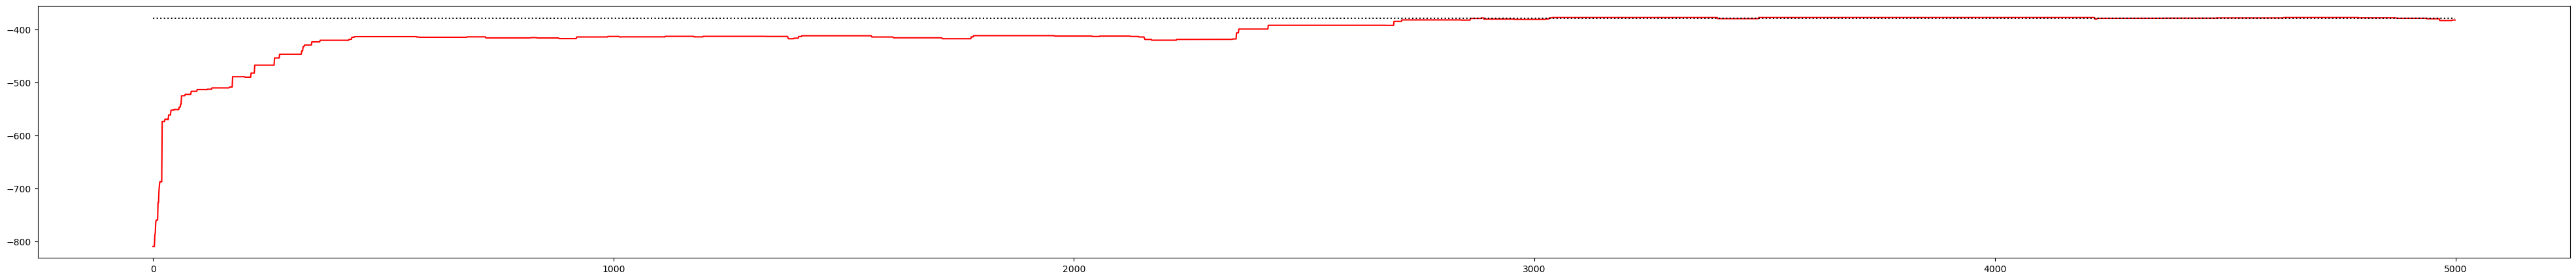

In [22]:
plt.figure(figsize=(50,5))
#Approximation
plt.plot(range(len(wvektor)),wvektor, color='red')
#Ursprungswahrscheinlichkeit
plt.plot(range(len(w1vektor)),w1vektor, color='black',linestyle='dotted')

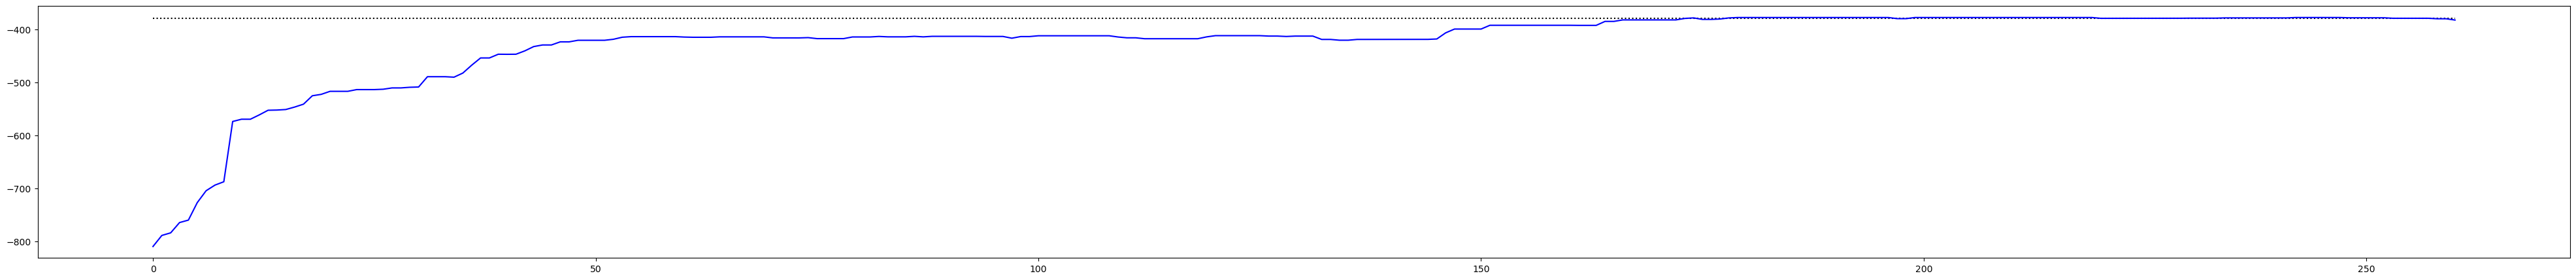

In [23]:
#nur bei Verbesserung wurde die Wahrscheinlichkeit übernommen
w1vektorb=[log_Ursprung]*len(bestvektor)
plt.figure(figsize=(50,5))
plt.plot(range(len(np.array(bestvektor))),w1vektorb, color='black',linestyle='dotted')
plt.plot(range(len(np.array(bestvektor))),np.array(bestvektor), color='blue')